In [1]:
%matplotlib inline
from secsy import cubedsphere as cs
from secsy import CSplot
from secsy import get_SECS_J_G_matrices, get_SECS_B_G_matrices
import lompe
import apexpy
import pyamps
import dipole
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import polplot
from pyamps.plot_utils import Polarsubplot
from pyamps import AMPS
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')
from my_utils import load_and_combine_dtu, load_omni, get_xiong_boundaries

from IPython.display import clear_output


In [2]:
RE = 6371.2e3
RI = RE + 110e3

theta0 = 0.25 # for j_G matrix singularity limit

Epoch = 2023 # REMEMBER TO CHANGE TO FIT DATA

# make cubed sphere projection and grid
location = (-40,71)
orientation = 0
L, W, Lres, Wres = 2500e3,3500e3,30,25

projection = cs.CSprojection(location, orientation)
grid = cs.CSgrid(projection, L, W, Lres, Wres, R = RI, wshift=1.0)

shp = grid.shape

# make lompe model, used to compute gradient matrices in magnetic east/west (conductances don't matter for us)
model = lompe.Emodel(grid, Hall_Pedersen_conductance = (0,0), epoch=Epoch, ew_regularization_limit=(70,90))

# Define meridian
mlon_m = 50
meridian_lat_qd = np.arange(60, 86+0.2, 0.2)
meridian_lon_qd = np.ones(len(meridian_lat_qd))*mlon_m

apex_obj = apexpy.Apex(date=datetime(2025, 2, 12), refh=110)
meridian_lat_geo, meridian_lon_geo = apex_obj.convert(meridian_lat_qd, meridian_lon_qd, 'qd', 'geo')

In [3]:
# Matrices to get predictions of B on meridian
depth = 350.0e3
#GeB_m, GnB_m, GuB_m = get_SECS_B_G_matrices(meridian_lat_geo, meridian_lon_geo, RE, grid.lat.flatten(), grid.lon.flatten())
GeB_m, GnB_m, GuB_m = get_SECS_B_G_matrices(meridian_lat_geo, meridian_lon_geo, RE, grid.lat.flatten(), grid.lon.flatten(), induction_nullification_radius = RE - depth)

# Matrices to get predictions of j on meridian
Gej_m, Gnj_m = get_SECS_J_G_matrices(meridian_lat_geo, meridian_lon_geo, grid.lat.flatten(), grid.lon.flatten(), singularity_limit = theta0 * np.pi / 180 * RI)

**INTERACTIVE PLOTTING**

In [25]:
times_sup = np.load('concurrent_times_supermag.npy',allow_pickle=True)
times_dtu = np.load('concurrent_times_dtu.npy',allow_pickle=True)
times = np.intersect1d(times_sup, times_dtu)

In [138]:
import glob
import os

# Your accepted times array
accepted_times = times_dtu  # modify as needed

# Your three folders
folders = [
    "dtu_downloads/yearly_BASELINE_rotated/GDH6"
]

all_dfs = []
for folder in folders:
    csv_files = glob.glob(os.path.join(folder, "*GDH_2023_11*"))
    if csv_files:
        all_dfs.append(pd.concat([pd.read_parquet(f, engine='fastparquet') for f in csv_files], ignore_index=True))

df_mag = pd.concat(all_dfs, ignore_index=True)

# Filter to accepted times only
df_mag['time'] = pd.to_datetime(df_mag['time'])
df_mag = df_mag[df_mag["time"].isin(accepted_times)]

# Sort by time then iaga
df_mag = df_mag.sort_values(by=["time"]).reset_index(drop=True)

#df_mag = df_mag.dropna(subset=['X','Y','Z'])
df_mag = df_mag.drop_duplicates(['time'])

In [139]:
window = 60

df_mag['H'] = np.sqrt(df_mag['X'].values**2 + df_mag['Y'].values**2)
rolling_mean = df_mag['H'].rolling(window=window, center=True, min_periods=1).mean()
    
# Subtract running mean
df_mag['H_hf'] = df_mag['H'] - rolling_mean.values

rolling_mean = df_mag['Z'].rolling(window=window, center=True, min_periods=1).mean()
    
# Subtract running mean
df_mag['Z_hf'] = df_mag['Z'] - rolling_mean.values

In [140]:
df_mag.head()

,time,X,Y,Z,t_mjd,H,H_hf,Z_hf
0,2023-11-01 00:00:00,-105.173713,52.505529,6.801907,8705.000000,117.551438,-2.379174,-20.424782
1,2023-11-01 00:06:00,-109.042042,50.597820,31.740050,8705.004167,120.209427,0.297011,4.572035
2,2023-11-01 00:06:01,-109.064298,50.762116,31.388258,8705.004178,120.298851,0.410154,4.275250
3,2023-11-01 00:06:02,-109.077761,51.067334,31.036466,8705.004190,120.440153,0.576896,3.971578
4,2023-11-01 00:06:03,-108.968399,51.083370,30.841026,8705.004201,120.347924,0.520227,3.819128


In [141]:
df_mag_plot = df_mag[(df_mag['time'] >= datetime(2023,11,7,0,0)) & (df_mag['time'] < datetime(2023,11,21,0,0))]
#df_mag_plot = df_mag_plot[::5]

In [ ]:
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scatter(x=df_mag_plot['time'].values, y=df_mag_plot['Z'].values, mode="lines", name="My Series"))

fig.update_layout(
    title="Interactive Time Series",
    xaxis_title="Date",
    yaxis_title="Value",
    xaxis=dict(rangeslider=dict(visible=True)),  # adds a range slider!
)

fig.show()

In [ ]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(rows=3, cols=1, shared_xaxes=True, vertical_spacing=0.05)

fig.add_trace(go.Scatter(x=df_mag_plot['time'].values, y=df_mag_plot['H'].values, mode="lines", name="H", connectgaps=False), row=1, col=1)
fig.add_trace(go.Scatter(x=df_mag_plot['time'].values, y=df_mag_plot['H_hf'].values, mode="lines", name="H_hf", connectgaps=False), row=2, col=1)
fig.add_trace(go.Scatter(x=df_mag_plot['time'].values, y=df_mag_plot['Z_hf'].values, mode="lines", name="Z_hf", connectgaps=False), row=3, col=1)


fig.update_layout(
    title="Interactive Time Series",
    xaxis3_title="Date",
    yaxis_title="H",
    yaxis2_title="H_hf",
    yaxis3_title="Z_hf",
    xaxis=dict(rangeslider=dict(visible=False)),
    xaxis2=dict(rangeslider=dict(visible=False)),
    xaxis3=dict(rangeslider=dict(visible=True))

)


fig.update_yaxes(range=[0, 400], row=1, col=1)
fig.update_yaxes(range=[-40, 40], row=2, col=1)
fig.update_yaxes(range=[-40, 40], row=3, col=1)


fig.show()

**INTERACTIVE PLOTTING OVER**

In [4]:
folders = ['GDH6', 'KUL2', 'KUV1', 'NAQ4m', 'NRD2', 'PIF4', 'SCO2', 'SKT1', 'STF2', 'SUM1', 'SVS1']
stations = np.load('stations_dtu.npy', allow_pickle=True)
times_dtu = np.load('concurrent_times_dtu.npy',allow_pickle=True)

In [5]:
# load dtu data
df_full = load_and_combine_dtu('20241111', folders, base_dir='dtu_downloads/yearly_BASELINE_rotated')

# Convert the 'Date_UTC' column to datetime objects
df_full = df_full.rename(columns={'time': 'Date_UTC', 'iaga': 'IAGA'})
df_full['Date_UTC'] = pd.to_datetime(df_full['Date_UTC'])

df_full.head()

,Date_UTC,X,Y,Z,t_mjd,IAGA
0,2024-11-01,-14.898905,-77.090828,16.687461,9071.0,GDH
1,2024-11-01,-17.017968,-40.211427,2.942397,9071.0,KUL
3,2024-11-01,44.266223,-68.856217,12.596224,9071.0,KUV
5,2024-11-01,38.697051,-45.336127,1.991581,9071.0,NAQ
7,2024-11-01,42.781469,-57.450720,-3.088776,9071.0,NRD


In [28]:
df_mag = df_full[(df_full['Date_UTC'] >= datetime(2024,11,30,0,30)) & (df_full['Date_UTC'] <= datetime(2024,11,30,3,0))]

In [29]:
na_mask = df_mag['X'].isna()
df_mag_na = df_mag[na_mask]
for stat in df_mag_na['IAGA'].unique():
    df_temp = df_mag_na[df_mag_na['IAGA']==stat]
    print(df_temp.shape[0])


df_mag_na['IAGA'].unique()

1


<ArrowStringArray>
['SUM']
Length: 1, dtype: str

In [30]:
## REMOVE STATIONS WITH MANY NANS
# Count NaNs in dbn_geo per station
nan_counts = (
    df_mag[df_mag['X'].isna()]
    .groupby('IAGA')
    .size()
)

# Find stations with more than 50000 NaNs
stations_to_remove = nan_counts[nan_counts > 1000].index

print("Stations to remove:")
print(stations_to_remove)

# Remove ALL data from those stations
df_mag = df_mag[
    ~df_mag['IAGA'].isin(stations_to_remove)
]

## REMOVE TIMES WHERE REMAINING NANS ARE
na_mask = df_mag['X'].isna()
times_na = df_mag['Date_UTC'][na_mask]
df_mag = df_mag[~df_mag['Date_UTC'].isin(times_na)]

Stations to remove:
Index([], dtype='str', name='IAGA')


In [31]:
stations = df_mag['IAGA'].unique()
times = df_mag['Date_UTC'].unique()

df_mag['U'] = -df_mag['Z']

# Pivot the entire DataFrame at once
# Rows = Stations, Columns = Time, Values = The 3 components
pivoted = df_mag.pivot(index='IAGA', columns='Date_UTC', 
                                values=['Y', 'X', 'U'])

# Ensure the rows (stations) and columns (time) stay in original order
pivoted = pivoted.reindex(index=stations, columns=times, level=1)

# Extract the three (21 x T) blocks and stack them vertically
# pivoted['column_name'] returns a (21, T) array
d = np.vstack([
    pivoted['Y'].values, 
    pivoted['X'].values, 
    pivoted['U'].values
])

# convert to nT
d = d * 1e-9

In [32]:
stations = df_mag['IAGA'].unique()

# Read CSV
STA = pd.read_csv("dtu_stations.csv")
iaga_column = "IAGA"
lat_column = "lat_gd"
lon_column = "lon_gd"

# Filter stations based on IAGA list (and sort by station name so it matches df_mag)
filtered_STA = STA[STA[iaga_column].isin(stations)].sort_values('IAGA')

# Extract latitude and longitude vectors
lat_mag = filtered_STA[lat_column].to_numpy()
lon_mag = filtered_STA[lon_column].to_numpy()

In [33]:
  
depth = 350e3 # depth where Br = 0 [m]
GeB_mag_mirror, GnB_mag_mirror, GuB_mag_mirror = get_SECS_B_G_matrices(lat_mag, lon_mag, RE, grid.lat, grid.lon, induction_nullification_radius = RE - depth)
#GeB_mag_mirror, GnB_mag_mirror, GuB_mag_mirror = get_SECS_B_G_matrices(lat_mag, lon_mag, RE, grid.lat, grid.lon)

# G matrix for the mirror current method:
G_mirror = np.vstack((GeB_mag_mirror, GnB_mag_mirror, GuB_mag_mirror)) # shape: (3*N, grid.size)

# Approach number 2: East-west minimization
Le, Ln, LTLe, LTLn = model.compute_L_matrices(grid) # get matrices that calculate MAGNETIC eastward and northward components of gradient
GTG_mirror, GTd_mirror = G_mirror.T.dot(G_mirror), G_mirror.T.dot(d) # we multiply the set of equations by G_mirror transpose
LTL = LTLe
T0, T1 = 5e-24, 1e-21 # regularization parameters from Walker
#T0, T1 = 1e-23, 1e-10 # less east/west reg
R = T0 * np.eye(grid.size) + T1 * LTL # regularization matrix
I_mirror = np.linalg.lstsq(GTG_mirror + R, GTd_mirror, rcond = 0)[0]

# Model predictions at meridian
Bu_m = GuB_m.dot(I_mirror)
je_m, jn_m = Gej_m.dot(I_mirror), Gnj_m.dot(I_mirror)

# GETTING MLT FOR EACH TIME/MERIDAN:
mlt = pyamps.mlon_to_mlt(mlon_m, times, Epoch)


In [66]:
for sta in stations:
    count = df_mag[df_mag['IAGA']==sta].shape[0]
    print(count,sta)

517 KUL
517 KUV
517 NAQ
517 PIF
517 SCO
517 STF
539 GDH
539 NRD
539 SKT
539 SUM
539 SVS


In [34]:
df_b = pd.DataFrame(columns=['time','MLT','clock_angle','Br','je','jn'])
df_b['time'] = times
#df_b.set_index('time', inplace=True)
df_b = df_b.sort_index()

df_b['MLT'] = mlt
df_b['Br'] = [Bu_m[:, i] for i in range(Bu_m.shape[1])]
df_b['je'] = [je_m[:, i] for i in range(je_m.shape[1])]
df_b['jn'] = [jn_m[:, i] for i in range(jn_m.shape[1])]

df_b.head()

,time,MLT,clock_angle,Br,je,jn
0,2024-11-30 00:30:00,22.933145,NaN,"[4.062353044184807e-09, 4.119358419188614e-09,...","[-0.0207393499987423, -0.022494069986241316, -...","[0.030249114490802722, 0.030552863519121846, 0..."
1,2024-11-30 00:30:01,22.933428,NaN,"[3.965529066822122e-09, 4.020369288251452e-09,...","[-0.02079401749346537, -0.02252621398873704, -...","[0.030174774819127833, 0.030478840506178197, 0..."
2,2024-11-30 00:30:02,22.933710,NaN,"[3.852206971900801e-09, 3.904525549834835e-09,...","[-0.020795897396375423, -0.022499200650269495,...","[0.029989517486372047, 0.03029310760938394, 0...."
3,2024-11-30 00:30:03,22.933993,NaN,"[3.7085414444916944e-09, 3.758761481818701e-09...","[-0.020780930005908506, -0.022445275409800267,...","[0.02980717347769847, 0.03011171890995418, 0.0..."
4,2024-11-30 00:30:04,22.934276,NaN,"[3.601429498125215e-09, 3.6498736724407444e-09...","[-0.020801709098452432, -0.022438832118191053,...","[0.029736274766885864, 0.030042948061481927, 0..."


In [41]:
na_times_b = df_b[df_b['Br'].apply(lambda x: any(isinstance(v, float) and np.isnan(v) for v in x))]['time'].tolist()

In [42]:
np.shape(na_times_b)

(0,)

In [40]:
has_nan = df_b['Br'].apply(lambda x: isinstance(x[0], float) and np.isnan(x[0]))

df_b['Br'] = df_b['Br'].where(~has_nan, other=df_b['Br'].shift(1))
df_b['je'] = df_b['je'].where(~has_nan, other=df_b['je'].shift(1))
df_b['jn'] = df_b['jn'].where(~has_nan, other=df_b['jn'].shift(1))

In [43]:
window = 60  # adjust as needed

for col in ['Br', 'je', 'jn']:
    # Expand lists into 2D array (time x meridian points)
    arr = np.array(df_b[col].tolist())
    
    # Compute rolling mean for each meridian point
    df_arr = pd.DataFrame(arr)
    rolling_mean = df_arr.rolling(window=window, center=True, min_periods=1).mean()
    
    # Subtract running mean
    result = arr - rolling_mean.values
    
    # Store back as lists in a new column
    df_b[f'{col}_hf'] = [row for row in result]

In [44]:
df_b.head()

,time,MLT,clock_angle,Br,je,jn,Br_hf,je_hf,jn_hf
0,2024-11-30 00:30:00,22.933145,NaN,"[4.062353044184807e-09, 4.119358419188614e-09,...","[-0.0207393499987423, -0.022494069986241316, -...","[0.030249114490802722, 0.030552863519121846, 0...","[1.194622097487376e-09, 1.207180560908363e-09,...","[-0.0004178701297550512, -0.000757376171132351...","[0.0016506223704150155, 0.0016345577555801315,..."
1,2024-11-30 00:30:01,22.933428,NaN,"[3.965529066822122e-09, 4.020369288251452e-09,...","[-0.02079401749346537, -0.02252621398873704, -...","[0.030174774819127833, 0.030478840506178197, 0...","[1.1213102902482104e-09, 1.1318131026792246e-0...","[-0.0004921405869950206, -0.000816386669986068...","[0.0016239370523597682, 0.0016079490340170297,..."
2,2024-11-30 00:30:02,22.933710,NaN,"[3.852206971900801e-09, 3.904525549834835e-09,...","[-0.020795897396375423, -0.022499200650269495,...","[0.029989517486372047, 0.03029310760938394, 0....","[1.0310906927990745e-09, 1.039170226622559e-09...","[-0.0005135132697464649, -0.000816032599393730...","[0.0014871816767687146, 0.0014705171428134288,..."
3,2024-11-30 00:30:03,22.933993,NaN,"[3.7085414444916944e-09, 3.758761481818701e-09...","[-0.020780930005908506, -0.022445275409800267,...","[0.02980717347769847, 0.03011171890995418, 0.0...","[9.07933381322809e-10, 9.139776024263261e-10, ...","[-0.000518882942321993, -0.0007889065689306064...","[0.0013523192218292818, 0.0013364785683253472,..."
4,2024-11-30 00:30:04,22.934276,NaN,"[3.601429498125215e-09, 3.6498736724407444e-09...","[-0.020801709098452432, -0.022438832118191053,...","[0.029736274766885864, 0.030042948061481927, 0...","[8.200847501798516e-10, 8.244222707777602e-10,...","[-0.0005595268463029941, -0.000808391386911848...","[0.0013277607118858045, 0.0013139713343694771,..."


In [51]:
#df_b_plot = df_b
df_b_plot = df_b[(df_b['time'] >= datetime(2024,11,30,1,15,0)) & (df_b['time'] <= datetime(2024,11,30,1,30,0))]
#df_b_plot = df_b_plot[(df_b['MLT'] >= 22.68) & (df_b_plot['MLT'] <= 22.78)]

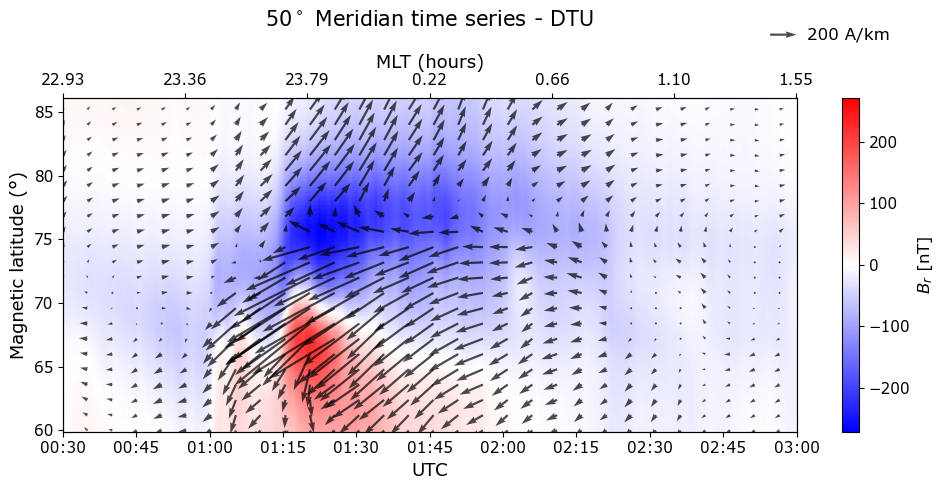

In [46]:
from matplotlib.colors import TwoSlopeNorm
import matplotlib.tri as tri
import matplotlib.dates as mdates

# Font size constants — tweak these to taste
FS_LABEL  = 13   # axis labels
FS_TICK   = 11   # tick labels
FS_TITLE  = 15   # title
FS_CBAR   = 12   # colorbar label
FS_QKEY   = 12   # quiver key label

# Your magnetic latitude array (shape: N_mlat)
mlat = meridian_lat_qd

# Stack the Br arrays into a 2D grid: shape (n_times, n_mlat)
Br_matrix = np.stack(df_b_plot['Br'].values * 1e9)   # shape: (n_times, n_mlat)
mlt_vals  = df_b_plot['MLT'].values         # shape: (n_times,)

# Build meshgrid for contourf
MLT_grid, MLAT_grid = np.meshgrid(mlt_vals, mlat, indexing='ij')

# Downsampling strides — tune these to taste
stride_mlt  = 5*60
stride_mlat = 6

# Stack je and jn the same way as Br
je_matrix = np.stack(df_b_plot['je'].values * 1e3)
jn_matrix = np.stack(df_b_plot['jn'].values * 1e3)

# Slice grids and vector components together
MLT_q  =  MLT_grid[::stride_mlt, ::stride_mlat]
MLAT_q = MLAT_grid[::stride_mlt, ::stride_mlat]
je_q   =   je_matrix[::stride_mlt, ::stride_mlat]
jn_q   =   jn_matrix[::stride_mlt, ::stride_mlat]

# Use UTC timestamps as x-axis base
utc_vals = df_b_plot['time'].values

# Build meshgrid with UTC on x
UTC_grid, MLAT_grid = np.meshgrid(utc_vals, mlat, indexing='ij')
UTC_q = UTC_grid[::stride_mlt, ::stride_mlat]

fig, ax = plt.subplots(figsize=(10, 5))

vmax = np.nanmax(np.abs(Br_matrix))
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
cf = ax.pcolormesh(
    UTC_grid, MLAT_grid, Br_matrix,
    cmap='bwr', norm=norm, shading='auto'
)
cbar = plt.colorbar(cf, ax=ax)
cbar.set_label('$B_r$ [nT]', fontsize=FS_CBAR)
cbar.ax.tick_params(labelsize=FS_TICK)

quiv = ax.quiver(
    UTC_q, MLAT_q,
    je_q, jn_q,
    color='k', scale=None,
    width=0.003, alpha=0.7
)
ax.quiverkey(quiv, X=1.0, Y=1.19, U=200,
             label='200 A/km', labelpos='E',
             fontproperties={'size': FS_QKEY})

# Bottom x-axis
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.set_xlabel('UTC', fontsize=FS_LABEL)
ax.set_ylabel('Magnetic latitude (°)', fontsize=FS_LABEL)
ax.tick_params(axis='both', labelsize=FS_TICK)

# Top x-axis: MLT
ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())

tick_step = len(utc_vals) // 6
tick_indices = np.arange(0, len(utc_vals), tick_step)
ax_top.set_xticks([mdates.date2num(utc_vals[i]) for i in tick_indices])
ax_top.set_xticklabels([f'{mlt_vals[i]:.2f}' for i in tick_indices])
ax_top.set_xlabel('MLT (hours)', fontsize=FS_LABEL)
ax_top.tick_params(axis='x', labelsize=FS_TICK)

ax.set_title('$50^\circ$ Meridian time series - DTU',
             size=FS_TITLE, pad=20)
plt.tight_layout()
#plt.savefig('meridian_time_series/20231113.png')
plt.show()

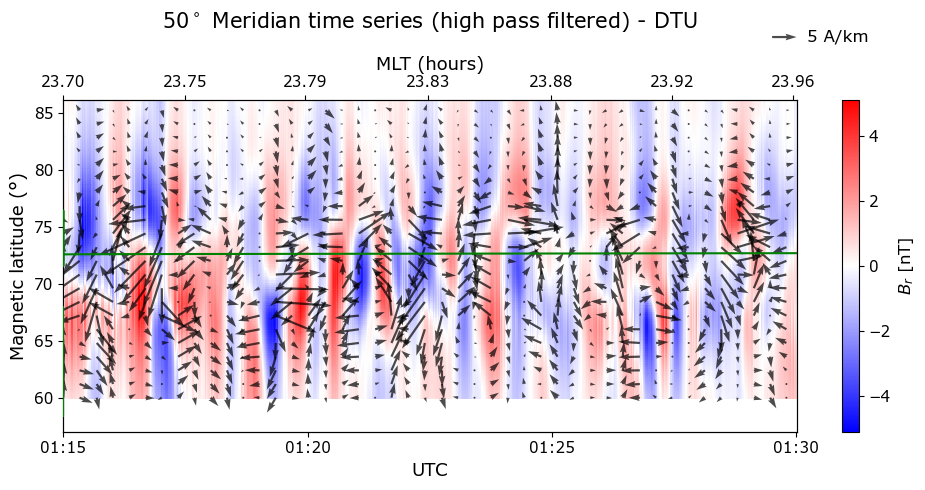

In [55]:
from matplotlib.colors import TwoSlopeNorm
import matplotlib.tri as tri
import matplotlib.dates as mdates

# Font size constants — tweak these to taste
FS_LABEL  = 13   # axis labels
FS_TICK   = 11   # tick labels
FS_TITLE  = 15   # title
FS_CBAR   = 12   # colorbar label
FS_QKEY   = 12   # quiver key label

# Your magnetic latitude array (shape: N_mlat)
mlat = meridian_lat_qd

# Stack the Br arrays into a 2D grid: shape (n_times, n_mlat)
Br_matrix = np.stack(df_b_plot['Br_hf'].values * 1e9)   # shape: (n_times, n_mlat)
mlt_vals  = df_b_plot['MLT'].values         # shape: (n_times,)

# Build meshgrid for contourf
MLT_grid, MLAT_grid = np.meshgrid(mlt_vals, mlat, indexing='ij')

# Downsampling strides — tune these to taste
stride_mlt  = 5*4
stride_mlat = 6

# Stack je and jn the same way as Br
je_matrix = np.stack(df_b_plot['je_hf'].values * 1e3)
jn_matrix = np.stack(df_b_plot['jn_hf'].values * 1e3)

# Slice grids and vector components together
MLT_q  =  MLT_grid[::stride_mlt, ::stride_mlat]
MLAT_q = MLAT_grid[::stride_mlt, ::stride_mlat]
je_q   =   je_matrix[::stride_mlt, ::stride_mlat]
jn_q   =   jn_matrix[::stride_mlt, ::stride_mlat]

# Use UTC timestamps as x-axis base
utc_vals = df_b_plot['time'].values

# Build meshgrid with UTC on x
UTC_grid, MLAT_grid = np.meshgrid(utc_vals, mlat, indexing='ij')
UTC_q = UTC_grid[::stride_mlt, ::stride_mlat]

fig, ax = plt.subplots(figsize=(10, 5))

vmax = np.nanmax(np.abs(Br_matrix))
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
cf = ax.pcolormesh(
    UTC_grid, MLAT_grid, Br_matrix,
    cmap='bwr', norm=norm, shading='auto'
)
cbar = plt.colorbar(cf, ax=ax)
cbar.set_label('$B_r$ [nT]', fontsize=FS_CBAR)
cbar.ax.tick_params(labelsize=FS_TICK)

quiv = ax.quiver(
    UTC_q, MLAT_q,
    je_q, jn_q,
    color='k', scale=None,
    width=0.003, alpha=0.7
)
ax.quiverkey(quiv, X=1.0, Y=1.19, U=5,
             label='5 A/km', labelpos='E',
             fontproperties={'size': FS_QKEY})

# Bottom x-axis
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.set_xlabel('UTC', fontsize=FS_LABEL)
ax.set_ylabel('Magnetic latitude (°)', fontsize=FS_LABEL)
ax.tick_params(axis='both', labelsize=FS_TICK)

# Top x-axis: MLT
ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())

tick_step = len(utc_vals) // 6
tick_indices = np.arange(0, len(utc_vals), tick_step)
ax_top.set_xticks([mdates.date2num(utc_vals[i]) for i in tick_indices])
ax_top.set_xticklabels([f'{mlt_vals[i]:.2f}' for i in tick_indices])
ax_top.set_xlabel('MLT (hours)', fontsize=FS_LABEL)
ax_top.tick_params(axis='x', labelsize=FS_TICK)

ax.set_title('$50^\circ$ Meridian time series (high pass filtered) - DTU',
             size=FS_TITLE, pad=20)

mlt_to_utc = np.interp(mlt_eq, mlt_vals, mdates.date2num(utc_vals))
ax_top.plot(mlt_to_utc, mlat_eq, color='green', zorder=20)
mlt_to_utc = np.interp(mlt_pw, mlt_vals, mdates.date2num(utc_vals))
ax_top.plot(mlt_to_utc, mlat_pw, color='green', zorder=20)

plt.tight_layout()
#plt.savefig('meridian_time_series/20231107_hi_freq_10_2.png')
plt.show()

**OCB STUFF**

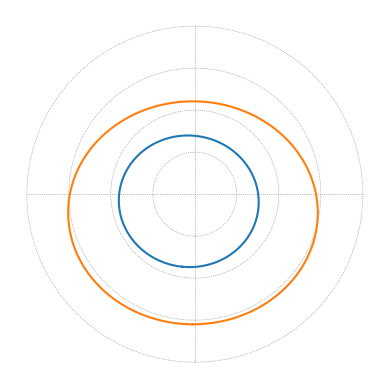

In [37]:
from my_utils import get_xiong_boundaries
from polplot import Polarplot

fig = plt.figure()
pax = Polarplot(fig.add_subplot(111), color = 'grey', linestyle = ':')
#epsilon = 1
#mlat_eq, mlt_eq, mlat_pw, mlt_pw, ee, ne, e_p, n_p = get_xiong_boundaries(epsilon, return_normal = True)
pax.plot(mlat_eq, mlt_eq)
pax.plot(mlat_pw, mlt_pw)
#pax.plotpins(mlat_eq, mlt_eq, ne, ee, SCALE = 1)
#mlat_eq, mlt_eq, mlat_pw, mlt_pw, ee, ne, e_p, n_p = get_xiong_boundaries(epsilon, hemisphere = 'south', return_normal = True)
#pax.plot(mlat_eq, mlt_eq, linestyle = '--')
#pax.plot(mlat_pw, mlt_pw, linestyle = '--')
#pax.plotpins(mlat_pw, mlt_pw, ne, ee, SCALE = 1)

plt.show()

In [53]:
from my_utils import load_omni
df_omni = []
mask_omni = []
for year in [2024]:
    df_omni_temp, mask_omni_temp = load_omni(f'omni_files/omni_{year}.lst', times=df_b_plot['time'].values, hourly=False)
    df_omni.append(df_omni_temp)
    mask_omni.append(mask_omni_temp)

df_omni = pd.concat(df_omni, ignore_index=False)
mask_omni = pd.concat(mask_omni, ignore_index=False)

In [54]:
mlat_eq, mlt_eq, mlat_pw, mlt_pw, ee, ne, e_p, n_p = get_xiong_boundaries(df_omni['by'].mean(),df_omni['bz'].mean(),df_omni['plasma_speed'].mean(), return_normal = True)
mlt_pw = np.array(mlt_pw)  # ensure it's a numpy array
mlt_pw = mlt_pw % 24

sort_indices = np.argsort(mlt_pw)
mlt_pw = mlt_pw[sort_indices]
mlat_pw = mlat_pw[sort_indices]

mlt_to_utc = np.interp(mlt_pw, mlt_vals, mdates.date2num(utc_vals))
ax_top.plot(mlt_to_utc, mlat_pw, color='green', zorder=20)


**Final plot thing**

In [29]:
df_b_plot_1 = pd.read_pickle("data_frames/df_b_plot_1.pkl")
df_b_plot_2 = pd.read_pickle("data_frames/df_b_plot_2.pkl")
df_b_plot_3 = pd.read_pickle("data_frames/df_b_plot_3.pkl")
df_b_plot_4 = pd.read_pickle("data_frames/df_b_plot_4.pkl")

In [30]:
from my_utils import load_omni
df_omni_1, _ = load_omni(f'omni_files/omni_2023.lst', times=df_b_plot_1['time'].values, hourly=False)
df_omni_2, _ = load_omni(f'omni_files/omni_2023.lst', times=df_b_plot_2['time'].values, hourly=False)
df_omni_3, _ = load_omni(f'omni_files/omni_2024.lst', times=df_b_plot_3['time'].values, hourly=False)
df_omni_4, _ = load_omni(f'omni_files/omni_2024.lst', times=df_b_plot_4['time'].values, hourly=False)


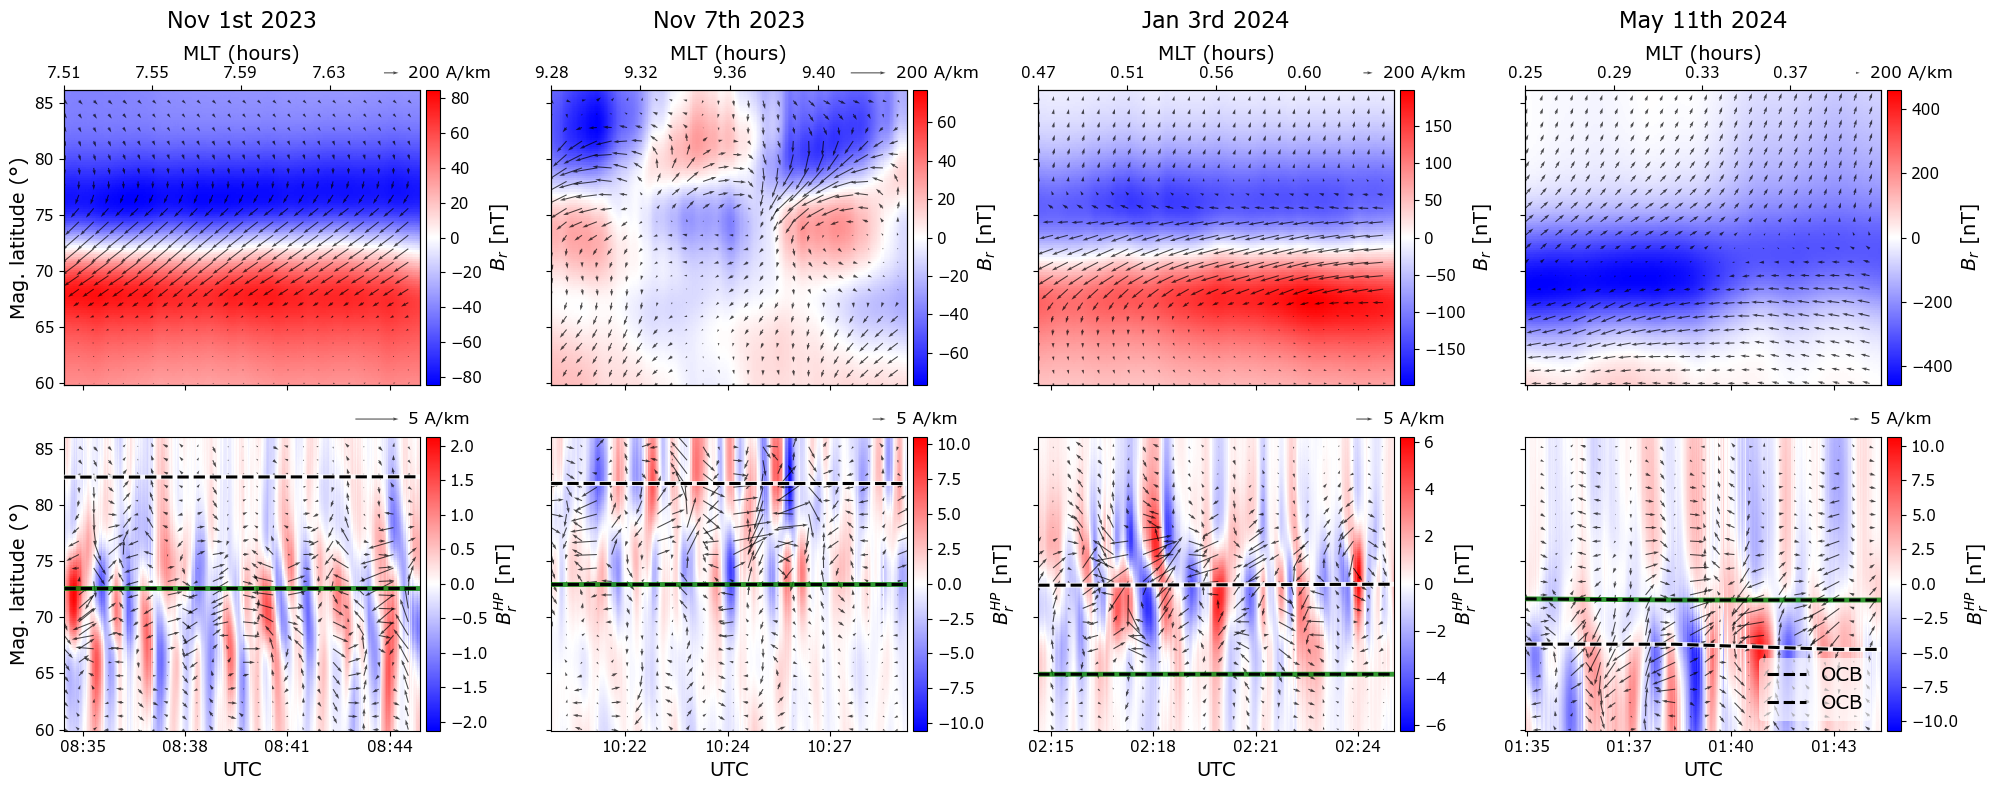

In [50]:
from matplotlib.colors import TwoSlopeNorm
from matplotlib.ticker import MaxNLocator
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np

# ── Font size constants ────────────────────────────────────────────────────────
FS_LABEL = 14
FS_TICK  = 11
FS_TITLE = 16
FS_CBAR  = 14
FS_QKEY  = 12

# ── Data sources: one entry per column ────────────────────────────────────────
datasets = [df_b_plot_1, df_b_plot_2, df_b_plot_3, df_b_plot_4]
df_omnis   = [df_omni_1,   df_omni_2,   df_omni_3,   df_omni_4]
titles   = ['Nov 1st 2023', 'Nov 7th 2023', 'Jan 3rd 2024', 'May 11th 2024']
mlat     = meridian_lat_qd

stride_mlt  = 5 * 5
stride_mlat = 6

# ── Row specs: (field_key, scale, unit_label, je_key, jn_key, quiverkey_U, quiverkey_label)
ROW_SPECS = [
    ('Br',    1e9, '$B_r$ [nT]',       'je',    'jn',    200, '200 A/km'),
    ('Br_hf', 1e9, '$B_r^{HP}$ [nT]', 'je_hf', 'jn_hf',  5,  '5 A/km'),
]
N_ROWS = len(ROW_SPECS)
N_COLS = len(datasets)

# ── Figure layout ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    N_ROWS, N_COLS,
    figsize=(5 * N_COLS, 4 * N_ROWS),
    sharey='row',
    squeeze=False,
)
fig.subplots_adjust(wspace=0.08, hspace=0.45)

# ── Helpers ───────────────────────────────────────────────────────────────────
def build_grids(df):
    utc_vals = df['time'].values
    mlt_vals = df['MLT'].values
    UTC_grid, MLAT_grid = np.meshgrid(utc_vals, mlat, indexing='ij')
    MLT_grid, _         = np.meshgrid(mlt_vals, mlat, indexing='ij')
    return utc_vals, mlt_vals, UTC_grid, MLAT_grid, MLT_grid

def build_quiver_grids(df, UTC_grid, MLAT_grid, je_key, jn_key):
    je_matrix = np.stack(df[je_key].values * 1e3)
    jn_matrix = np.stack(df[jn_key].values * 1e3)
    UTC_q  =  UTC_grid[::stride_mlt, ::stride_mlat]
    MLAT_q = MLAT_grid[::stride_mlt, ::stride_mlat]
    je_q   =  je_matrix[::stride_mlt, ::stride_mlat]
    jn_q   =  jn_matrix[::stride_mlt, ::stride_mlat]
    return UTC_q, MLAT_q, je_q, jn_q

# ── Main plotting loop ────────────────────────────────────────────────────────
for col, (df, df_omni, col_title) in enumerate(zip(datasets, df_omnis, titles)):

    utc_vals, mlt_vals, UTC_grid, MLAT_grid, MLT_grid = build_grids(df)

    for row, (b_key, b_scale, cbar_label, je_key, jn_key, qU, qLabel) in enumerate(ROW_SPECS):

        ax = axes[row, col]

        # ── pcolormesh ────────────────────────────────────────────────────────
        B_matrix = np.stack(df[b_key].values * b_scale)
        vmax = np.nanmax(np.abs(B_matrix))
        norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

        cf = ax.pcolormesh(
            UTC_grid, MLAT_grid, B_matrix,
            cmap='bwr', norm=norm, shading='auto'
        )

        # ── individual colorbar ───────────────────────────────────────────────
        cbar = plt.colorbar(cf, ax=ax, pad=0.015, fraction=0.046)
        cbar.set_label(cbar_label, fontsize=FS_CBAR)
        cbar.ax.tick_params(labelsize=FS_TICK)

        # ── quivers ───────────────────────────────────────────────────────────
        UTC_q, MLAT_q, je_q, jn_q = build_quiver_grids(
            df, UTC_grid, MLAT_grid, je_key, jn_key
        )
        quiv = ax.quiver(
            UTC_q, MLAT_q, je_q, jn_q,
            color='k', scale=None, width=0.003, alpha=0.7
        )

        # Per-row quiverkey with its own reference magnitude
        ax.quiverkey(quiv, X=0.94, Y=1.06, U=qU,
                     label=qLabel, labelpos='E',
                     fontproperties={'size': FS_QKEY})

        # ── UTC x-axis: fixed number of ticks ─────────────────────────────────
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        ax.xaxis.set_major_locator(MaxNLocator(nbins=4, prune='both'))  # ← 4 ticks max, prune edges
        ax.tick_params(axis='both', labelsize=FS_TICK)

        if col == 0:
            ax.set_ylabel('Mag. latitude (°)', fontsize=FS_LABEL)

        if row == N_ROWS - 1:
            ax.set_xlabel('UTC', fontsize=FS_LABEL)
        else:
            ax.set_xticklabels([])

        # ── MLT top axis (row 0 only) ─────────────────────────────────────────
        if row == 0:
            ax_top = ax.twiny()
            ax_top.set_xlim(ax.get_xlim())
            tick_step    = max(len(utc_vals) // 4, 1)           # ← match 4 ticks
            tick_indices = np.arange(0, len(utc_vals), tick_step)[:4]  # ← cap at 4
            ax_top.set_xticks([mdates.date2num(utc_vals[i]) for i in tick_indices])
            ax_top.set_xticklabels([f'{mlt_vals[i]:.2f}' for i in tick_indices],
                                   fontsize=FS_TICK)
            ax_top.set_xlabel('MLT (hours)', fontsize=FS_LABEL)
            ax.set_title(col_title, fontsize=FS_TITLE, pad=45)
        else:
            ax.set_title(' ', fontsize=FS_TITLE, pad=8)
        
        # ── OCB line (bottom row only) ─────────────────────────────────────────
        if row == 1:
            mlat_eq, mlt_eq, mlat_pw, mlt_pw, ee, ne, e_p, n_p = get_xiong_boundaries(
                df_omni['by'].mean(),
                df_omni['bz'].mean(),
                df_omni['plasma_speed'].mean(),
                return_normal=True
            )
            mlt_pw = np.array(mlt_pw) % 24
            sort_idx = np.argsort(mlt_pw)
            mlt_pw  = mlt_pw[sort_idx]
            mlat_pw = np.array(mlat_pw)[sort_idx]

            mlt_eq = np.array(mlt_eq) % 24
            sort_idx = np.argsort(mlt_eq)
            mlt_eq  = mlt_eq[sort_idx]
            mlat_eq = np.array(mlat_eq)[sort_idx]

            # ── Clip to visible MLT window with a small pad to reach plot edges ────
            mlt_min, mlt_max = mlt_vals.min(), mlt_vals.max()
            pad = (mlt_max - mlt_min) * 0.05          # 5% padding on each side
            mask = (mlt_pw >= mlt_min - pad) & (mlt_pw <= mlt_max + pad)
            mlt_pw  = mlt_pw[mask]
            mlat_pw = mlat_pw[mask]
            mlt_eq  = mlt_eq[mask]
            mlat_eq = mlat_eq[mask]

            if len(mlt_pw) == 0:
                continue

            # Interpolate — np.interp clamps by default at the boundary values
            mlt_to_utc = np.interp(mlt_pw, mlt_vals, mdates.date2num(utc_vals))
            
            # Resample OCB onto a dense grid matching your MLT range exactly
            mlt_dense   = np.linspace(mlt_min, mlt_max, 500)
            mlat_dense  = np.interp(mlt_dense, mlt_pw, mlat_pw)   # fills gaps by linear interp
            mlat_dense_eq  = np.interp(mlt_dense, mlt_eq, mlat_eq)   # fills gaps by linear interp
            utc_dense   = np.interp(mlt_dense, mlt_vals, mdates.date2num(utc_vals))

            ax.plot(utc_dense, mlat_dense,
                    color='white', linewidth=3.5, zorder=19, alpha=0.8)
            ax.plot(utc_dense, mlat_dense,
                    color='black', linewidth=2.2, linestyle='--', zorder=20,
                    label='OCB')
            #ax.plot(utc_dense, mlat_dense_eq,
            #        color='green', linewidth=3.5, zorder=19, alpha=0.8)
            #ax.plot(utc_dense, mlat_dense_eq,
            #        color='black', linewidth=2.2, linestyle='--', zorder=20,
            #        label='OCB')


            if col == N_COLS - 1:
                ax.legend(fontsize=FS_TICK+3, loc='lower right',
                        framealpha=0.6, edgecolor='none')
                
#fig.suptitle('Meridian time series — DTU', fontsize=FS_TITLE + 2, y=1.01)
plt.tight_layout()
plt.show()

In [26]:
df_b_plot.to_pickle("data_frames/df_b_plot_4.pkl")
df_b_plot_4 = pd.read_pickle("data_frames/df_b_plot_4.pkl")